In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, ifft

$X_{k} = \sum_{n=0}^{N-1} x_{n}e^{\frac{-i2\pi kn}{N}}$ 

$x_{n} = \frac{1}{N}\sum_{k=0}^{N-1} X_{k}e^{\frac{i2\pi kn}{N}}$

k, n are indices, so should have same length. N is the number of datapoints. 

In [88]:
def func(x):
    return np.exp(-50*(x-0.5)**2)

def f_func(k):
    return np.sqrt(np.pi/50)*np.exp(-0.5*1j*k-(k**2/200))

def xk_func(x,k,N,n):
    return x*np.exp(-1j*2*np.pi*(k/N)*n) #1j is the python notation for -1........turns out that's the engineers' fault

def xn_func(x,k,N,n):
    return x*np.exp(1j*2*np.pi*(k/N)*n)

def DFT_set(x):
    N = len(x)
    xk = np.zeros(N,dtype=complex) #making an empty array that has the length of N. Setting it up just in case I have complex numbers

    for k in range(N):
        for n in range(N):
            xk[k] += xk_func(x[n], k, N, n)

    return xk

def IDFT_set(x):
    N = len(x)
    xn = np.zeros(N,dtype=complex) #making an empty array that has the length of N. Setting it up just in case I have complex numbers

    for n in range(N):
        for k in range(N):
            xn[n] += xn_func(x[k], k, N, n)

    return xn/N

def DFT(N):
    x = np.linspace(0,1,N) #problem says on domain [0,1]
    xn = func(x)

    xk = DFT_set(xn)
    xn_in = IDFT_set(xk)

    return x, xn, xk, xn_in

In [82]:
N=100
x = np.linspace(0,1,N) #my x range in domain [0,1]
k = np.arange(0,N,1)
og = []
xk = []
xn = []

for k in range(0,N-1):
    for n in range(0,N-1):
        #print(k,n)
        og_vals = sum(func(x))
        xk_vals = xk_func(x,k,N,n)
        xn_vals = xn_func(x,k,N,n)
        
        og.append(og_vals)
        xk.append(xk_vals)     
        xn.append(xn_vals)     

In [83]:
k

98

ValueError: x and y must be the same size

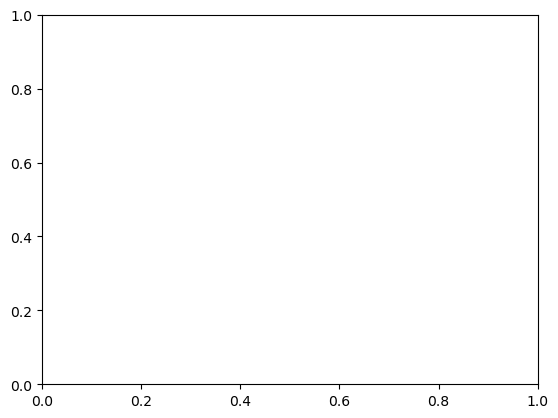

In [85]:
plt.scatter(x,og)
#plt.scatter(x,abs(xk[0]))

In [54]:
N=50
x = np.linspace(0,1,N) #my x range in domain [0,1]
x.shape
func(x)
#plt.scatter(x,func(x))

np.float64(12.282474606487865)

In [92]:
#Making the discrete Fourier transform
def func(x):
    return np.exp(-50*(x-0.5)**2)

# def q1_res_k(k):
#     x = np.linspace(0,1,N)
#     return np.sqrt(np.pi/50)*np.exp(-0.5*1j*k-(k**2/200))

def xk_func(xn,k,N,n):
    return xn*np.exp(-1j*2*np.pi*(k/N)*n) #1j is the python notation for -1........turns out that's the engineers' fault

def xn_func(xk,k,N,n):
    return xk*np.exp(1j*2*np.pi*(k/N)*n)

def DFT_set(x):
    N = len(x)
    xk = np.zeros(N,dtype=complex) #making an empty array that has the length of N. Setting it up just in case I have complex numbers

    for k in range(N):
        for n in range(N):
            xk[k] += xk_func(x[n], k, N, n)

    return xk

def IDFT_set(x):
    N = len(x)
    xn = np.zeros(N,dtype=complex) #making an empty array that has the length of N. Setting it up just in case I have complex numbers

    for n in range(N):
        for k in range(N):
            xn[n] += xn_func(x[k], k, N, n)

    return xn/N

def DFT(N):
    x = np.linspace(0,1,N) #problem says on domain [0,1]
    dx = x[1] - x[0]
    xn = func(x)

    xk = DFT_set(xn)*dx 
    xn_in = IDFT_set(xk)

    return x, xn, xk, xn_in

def kvals(N,L=1):
    k = np.zeros(N)
    
    for m in range(N):
        if m <= N//2:
            k[m] = 2*np.pi*m / L
        else:
            k[m] = 2*np.pi*(m - N) / L
    return k

In [96]:
#Doing the Fourier transform
def compute_fft(func, x):
    ft = fft(func)
    freqs = fftfreq(len(x), x[1] - x[0])  # Get actual frequencies
    return np.abs(freqs), ft

freqs, ft = fft_curve(func,x) 
plt.plot(freqs, ft)

NameError: name 'fft_curve' is not defined

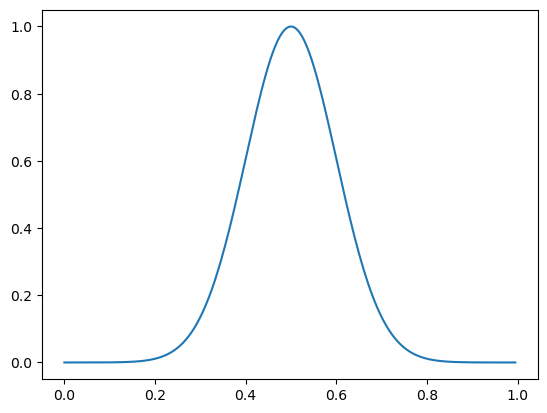

In [98]:
#Inverse Fourier to check if get the same thing back
def inverse_fft(ft):
    inverse = ifft(ft)
    return inverse

inverse = inverse_fft(ft)
plt.plot(x, np.real(inverse))